In [71]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import scipy as sp
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

<a id="Parameters"></a>
# Parameters

In [146]:
# Genotype Global Variables
GENOTYPE_FP = "genotypes.xls"
CHROMOSOME_FIELD = "Chr_Build37"
GENOTYPE_POSITION_FIELD = "Build37_position"

In [147]:
# Gene Expression Global Variables
GENE_EXP_FP = "dendritic_LPS_stimulation.txt"
GENE_POSITION_FP = "MGI_Coordinates.Build37.rpt.txt"
GENE_POSITION_FIELDS = ["representative genome start", "representative genome end"]
GENE_TYPE = 'marker type'
GENE_NAME_FIELD = "marker symbol"
GENE_CHROMOSOME_FIELD = "representative genome chromosome"

# Define function

In [198]:
def is_cis(eQTL_lst, genes_positions_df, snps_positions_df, cis_distance):
    new_eQTL_lst = eQTL_lst.copy()
    for m in range(0, len(eQTL_lst)):
        gene = new_eQTL_lst[m][0]
        snp = new_eQTL_lst[m][1]
        snp_chr = snps_positions_df[snps_positions_df['Locus'] == snp][CHROMOSOME_FIELD].values[0]
        gene_chr = genes_positions_df.loc[gene][GENE_CHROMOSOME_FIELD]
        if snp_chr == gene_chr:
            gene_start = genes_positions.loc[gene][GENE_POSITION_FIELDS[0]]
            gene_end = genes_positions.loc[gene][GENE_POSITION_FIELDS[1]]
            snp_pos = genotypes_to_use[genotypes_to_use['Locus'] == snp][GENOTYPE_POSITION_FIELD].values[0]
            if (abs(gene_start - snp_pos) <= cis_distance) | (abs(snp_pos - gene_end) <= cis_distance):
                new_eQTL_lst[m].append('cis')
            else:
                new_eQTL_lst[m].append('trans')
        else:
            new_eQTL_lst[m].append('trans')
    return new_eQTL_lst

In [162]:
def f_test(r_square, n, k):
    dfn = n - 2
    dfd = k - 1
    f_statistics = r_square / ((1 - r_square) / (n - 2))
    # print("f_statistics: ", f_statistics)
    p_value0 = 1 - sp.stats.f.cdf(f_statistics, dfd, dfn)
    return p_value0

In [163]:
def linear_reg_func(x, y):
    k = 2
    n = x.shape[0]
    mean_x = x.mean()
    mean_y = y.mean()
    var_x = x.var()
    cov_x_y = (sum(x * y) - (n * mean_x * mean_y)) / (n - 1)
    # calculate b0, b1
    b1 = cov_x_y / var_x
    b0 = mean_y - (b1 * mean_x)
    # calculate p-value
    y_hat = b0 + b1 * x
    sse = sum(np.square(y - y_hat))
    ssr = sum((np.square(y_hat - mean_y)))
    sst = sse + ssr
    r_square = ssr / sst
    p_value1 = f_test(r_square, n, k)
    return b0, b1, p_value1

<a id="Get_Data"></a>
# Get Data

In [149]:
genotypes = pd.read_excel(GENOTYPE_FP, index_col=0, skiprows=1)  # use pip install xlrd if error raise
phenotypes = pd.read_csv(GENE_EXP_FP, index_col=0, sep='\t')
MGI_data = pd.read_csv(GENE_POSITION_FP, index_col=2, sep='\t')

In [150]:
MGI_data = MGI_data[MGI_data[GENE_TYPE] == 'Gene']
genes_positions = MGI_data[
    [GENE_CHROMOSOME_FIELD, GENE_POSITION_FIELDS[0], GENE_POSITION_FIELDS[1]]]

<a id="Preprocessing"></a>
# Preprocessing

In [151]:
relative_positions_list_tmp = [195154279, 181755017, 159745316, 156860686, 151758149, 149588044, 144995196, 130127694,
                               124359700, 130530862, 121973369, 120092757, 120883175, 125139656, 104073951, 98008968,
                               95294699, 90720763, 61420004]
relative_positions_list = [195154279]
for i in range(1, len(relative_positions_list_tmp)):
    relative_positions_list.append(relative_positions_list[i - 1] + relative_positions_list_tmp[i])

Sort by location

In [152]:
genotypes = genotypes.sort_values(by=[CHROMOSOME_FIELD, GENOTYPE_POSITION_FIELD])

In [155]:
genes_positions.dropna(inplace=True)
genes_positions = genes_positions[~genes_positions[GENE_CHROMOSOME_FIELD].isin(['MT', 'Y'])]
genes_positions = genes_positions.astype('int32').sort_values(by=[GENE_CHROMOSOME_FIELD])

Get strains that are in both files

In [156]:
genotypes_strain_set = set([col for col in genotypes.columns if 'BXD' in col])
phenotypes_strain_set = set([col.split("_")[0] for col in phenotypes.columns])
shared_strain_set = genotypes_strain_set & phenotypes_strain_set
shared_strain_list = list(shared_strain_set)

# Filtering those loci that have exactly the same information as neighboring loci across the BXD strains under study

In [157]:
prev_snp = genotypes.loc[1]
snps_to_remove = list()
for i in range(2, genotypes.shape[0]):
    curr_snp = genotypes.loc[i]
    if curr_snp[CHROMOSOME_FIELD] == prev_snp[CHROMOSOME_FIELD]:  #same chromosome
        if curr_snp[shared_strain_list].equals(prev_snp[shared_strain_list]):
            snps_to_remove.append(curr_snp['Locus'])
    prev_snp = genotypes.loc[i]

In [158]:
#filter
genotypes_to_use = genotypes[~genotypes['Locus'].isin(snps_to_remove)]

# Average gene expression data across different individuals of the same strain

In [159]:
phenotypes_to_use = pd.DataFrame(index=phenotypes.index)
for strain in phenotypes_strain_set:
    phenotypes_to_use[strain] = phenotypes.filter(like=strain).mean(axis=1)

Filter to strains that are in both files

In [160]:
genotypes_for_calc, phenotypes_for_calc = genotypes_to_use.align(phenotypes_to_use, join='inner', axis=1)

Change to numeric values for calc

In [161]:
# genotypes_for_calc = genotypes_for_calc.applymap(lambda strain: 0 if strain == 'B' else (2 if strain == 'D' else 1))
# Define the mapping of values to be replaced
mapping = {'B': 0, 'b': 0, 'D': 2, 'd': 2, 'H': 1, 'h': 1}
for col in genotypes_for_calc:
    genotypes_for_calc[col] = genotypes_for_calc[col].replace(mapping)

<a id="association_tests"></a>
# Association tests

<b>Read p-val file

In [164]:
p_vals_list = list()
for i, exp in enumerate(phenotypes_for_calc.iterrows()):
    p_vals_list.append(list())
    for snp in genotypes_for_calc.iterrows():
        p_val = linear_reg_func(x=snp[1].to_numpy(), y=exp[1].to_numpy())[2]
        # p_vals_dict[exp[0]].append((snp,p_val))
        p_vals_list[i].append(p_val)

In [166]:
p_vals_df = pd.DataFrame(p_vals_list, index=phenotypes_for_calc.index, columns=genotypes_to_use['Locus'].tolist())
p_vals_df.to_excel('p_vals_df.xlsx')
p_vals_df = pd.read_excel('p_vals_df.xlsx', index_col=0)

<b>FDR

In [167]:
corrected_p_vals_array = multipletests(p_vals_df.values.flatten(), method="fdr_bh")[1]

In [168]:
corrected_p_vals_df = pd.DataFrame(np.reshape(corrected_p_vals_array, (403, 1525)), columns=p_vals_df.columns,
                                   index=p_vals_df.index)

<b>Get eQTLs

In [169]:
corrected_p_vals_df_T = corrected_p_vals_df.T

In [170]:
eQTLs_dict = dict()
eQTLS_list = list()
for i in range(0, corrected_p_vals_df.T.shape[0]):
    snp_p_vals = corrected_p_vals_df_T.iloc[i]
    significant_snp_p_vals = snp_p_vals[snp_p_vals <= 0.05]
    if significant_snp_p_vals.empty:
        eQTLs_dict[significant_snp_p_vals.name] = []
    else:
        for gene in significant_snp_p_vals.index.tolist():
            eQTLS_list.append([gene, significant_snp_p_vals.name])
        eQTLs_dict[significant_snp_p_vals.name] = significant_snp_p_vals.index.tolist()

In [171]:
eQTLs_clean_dict = {x: y for x, y in eQTLs_dict.items() if len(y) != 0}

In [172]:
#get list of significant genes
eQTLS_genes = list(eQTLs_dict.values())
eQTLS_genes_list = [j for sub in eQTLS_genes for j in sub]
eQTLS_genes_list = list(dict.fromkeys(eQTLS_genes_list))

In [173]:
len(eQTLS_list)

264

<b>Fix positions

Genotypes position

In [174]:
genotypes_to_use_relative_pos = genotypes_to_use[genotypes_to_use[CHROMOSOME_FIELD] == 1].copy()
for i in range(2, 21):
    genotypes_chr_i = genotypes_to_use[genotypes_to_use[CHROMOSOME_FIELD] == i].copy()
    genotypes_chr_i[GENOTYPE_POSITION_FIELD] = genotypes_chr_i[GENOTYPE_POSITION_FIELD].apply(
        lambda x: x + relative_positions_list[i - 2])
    genotypes_to_use_relative_pos = pd.concat([genotypes_to_use_relative_pos, genotypes_chr_i], axis=0)

In [175]:
genotypes_to_use_relative_pos[GENOTYPE_POSITION_FIELD] = genotypes_to_use_relative_pos[GENOTYPE_POSITION_FIELD].apply(
    lambda x: x / (1000 ** 2))

Genes positions

In [176]:
genes_positions_relative_pos = genes_positions[genes_positions[GENE_CHROMOSOME_FIELD] == 1].copy()
for i in range(2, 21):
    genes_chr_i = genes_positions[genes_positions[GENE_CHROMOSOME_FIELD] == i].copy()
    genes_chr_i['representative genome start'] = genes_chr_i['representative genome start'].apply(
        lambda x: x + relative_positions_list[i - 2])
    genes_chr_i[GENE_POSITION_FIELDS[1]] = genes_chr_i[GENE_POSITION_FIELDS[1]].apply(
        lambda x: x + relative_positions_list[i - 2])
    genes_positions_relative_pos = pd.concat([genes_positions_relative_pos, genes_chr_i], axis=0)

In [177]:
genes_positions_relative_pos[GENE_POSITION_FIELDS[0]] = genes_positions_relative_pos[
    GENE_POSITION_FIELDS[0]].apply(lambda x: x / (1000 ** 2))
genes_positions_relative_pos[GENE_POSITION_FIELDS[1]] = genes_positions_relative_pos[
    GENE_POSITION_FIELDS[1]].apply(lambda x: x / (1000 ** 2))

<b>Plot number of genes associated with each eQTL across the genome

In [178]:
eQTLs_num_genes_dict = {x: len(y) for x, y in eQTLs_dict.items()}

In [179]:
genotypes_info = genotypes_to_use_relative_pos[['Locus', CHROMOSOME_FIELD, GENOTYPE_POSITION_FIELD]]
genotypes_info.set_index('Locus', inplace=True)
genotypes_info_with_eQTLs = pd.concat([genotypes_info, pd.DataFrame.from_dict(eQTLs_num_genes_dict, orient='index')],
                                      axis=1)
genotypes_info_with_eQTLs.rename(columns={0: 'num_associated_genes'}, inplace=True)

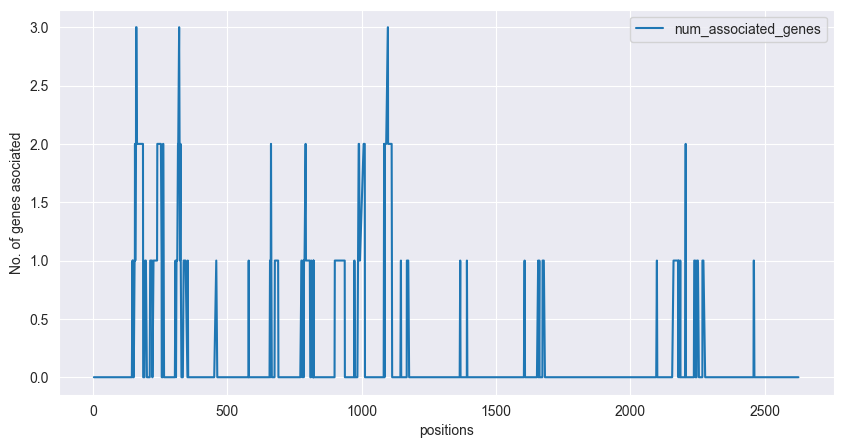

In [180]:
genotypes_info_with_eQTLs.plot.line(x=GENOTYPE_POSITION_FIELD, y='num_associated_genes', figsize=(10, 5))
plt.xlabel("positions")
plt.ylabel("No. of genes asociated")
plt.savefig('eQTL')

<b>Check cis/trans

In [181]:
eQTLS_list_cis_trans = is_cis(eQTLS_list, genes_positions, genotypes_to_use, cis_distance=(2 * (1000 ** 2)))

In [182]:
#add p-values
for pair in eQTLS_list_cis_trans:
    pair.append(corrected_p_vals_df.loc[pair[0], pair[1]])

In [183]:
eQTLS_cis_trans_df = pd.DataFrame(data=eQTLS_list_cis_trans, columns=['gene', 'snp', 'cis/trans', 'p-value'])

In [ ]:
trans = eQTLS_cis_trans_df[eQTLS_cis_trans_df['cis/trans'] == 'trans']
cis = eQTLS_cis_trans_df[eQTLS_cis_trans_df['cis/trans'] == 'cis']

<b> P-values distributions

In [185]:
tran_mean = trans['p-value'].mean()
cis_mean = cis['p-value'].mean()
tran_std = trans['p-value'].std()
cis_std = cis['p-value'].std()

In [186]:
print(tran_mean, cis_mean, tran_std, cis_std)

0.011674133644187849 0.006180764203183807 0.013801062411631215 0.009561951363719708


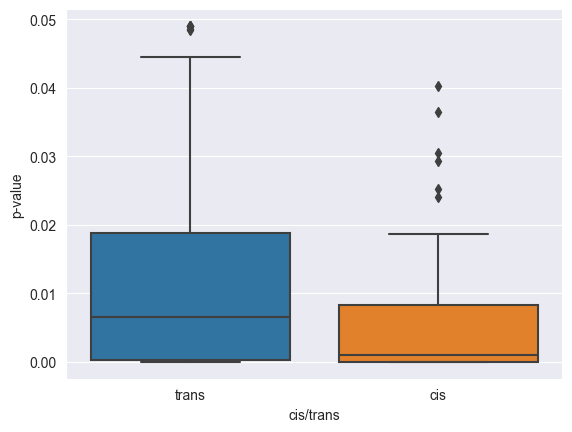

In [187]:
sns.boxplot(x="cis/trans", y="p-value", data=eQTLS_cis_trans_df)
plt.savefig('statistics')

()

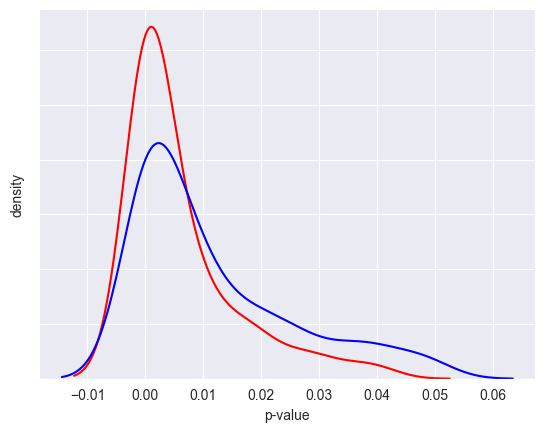

In [200]:
def create_distribution_graph(df):
    cis = df.loc[df['cis/trans'] == 'cis']
    cis = cis['p-value']
    trans = df.loc[df['cis/trans'] == 'trans']
    trans = trans['p-value']
    g = sns.kdeplot(cis, color="r", label='cis')
    sns.kdeplot(trans, color="b", label='trans')
    g.set(yticklabels=[])
    g.set_ylabel('density')
    g.set_xlabel('p-value')
    plt.savefig('graph.png')
    return ()


create_distribution_graph(eQTLS_cis_trans_df)

<b> Scatter plot visualization of the marker positions vs the genes positions

In [189]:
genes_pos = genes_positions_relative_pos[genes_positions_relative_pos.index.isin(eQTLS_cis_trans_df['gene'].tolist())][
    'representative genome start']
snps_pos = \
    genotypes_to_use_relative_pos[genotypes_to_use_relative_pos['Locus'].isin(eQTLS_cis_trans_df['snp'].tolist())][
        ['Locus', GENOTYPE_POSITION_FIELD]]

In [194]:
scatter_plot = eQTLS_cis_trans_df.merge(genes_pos, how='inner', left_on='gene', right_index=True).merge(snps_pos,
                                                                                                        how='inner',
                                                                                                        left_on='snp',
                                                                                                        right_on='Locus').drop(
    columns='Locus')

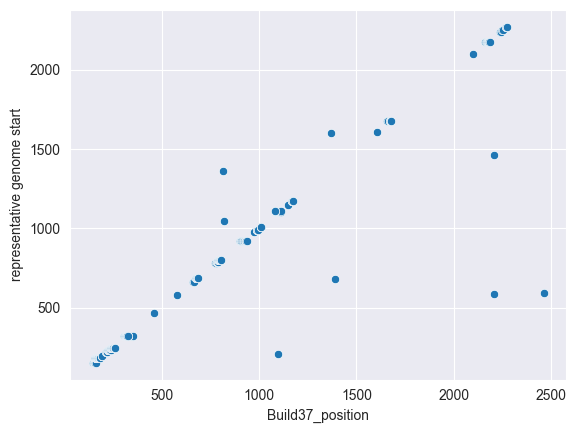

In [195]:
sns.scatterplot(data=scatter_plot, x=GENOTYPE_POSITION_FIELD, y='representative genome start')
plt.savefig('scatter plot')

<b> Export

In [196]:
scatter_plot.rename(
    columns={GENE_POSITION_FIELDS[0]: 'gene location', GENOTYPE_POSITION_FIELD: 'snp location'}).to_excel(
    'eQTLs_results.xlsx')